## Calving series statistics for Jakobshavn Isbrae ##

This notebook is the introduction to fitting statistical parameters to characterize the calving (length) time series for glacier Jakobshavn Isbrae in Greenland. 

A Poisson process models random events occurring in time (or space) where:
- Events occur independently
- The average rate of events is constant: 𝜆
- Number of events through time N(t)

Note that there is a difference between a Poisson process and a compound Poisson process. 



In [1]:
# Notebook set up: import dependencies and load in data
# Run this on greenlandMapping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fractions
import scipy
import xarray as xr
from matplotlib.collections import LineCollection
import jump_process # dans .py 
from scipy.stats import poisson

In [2]:
# plotting parameters
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# colors
dark_blue = "#143e78"
blue = "#25689e"
light_blue = "#8fc8e6"
middle_blue = "#3f8bb7"
light_purple = "#7f6ec2"
teal = "#149c9c"
blue_2 = "#355166"


### 1. Simulating a Poisson process ###

Objective is to _"write some code simulating a poisson process"_

Starting here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

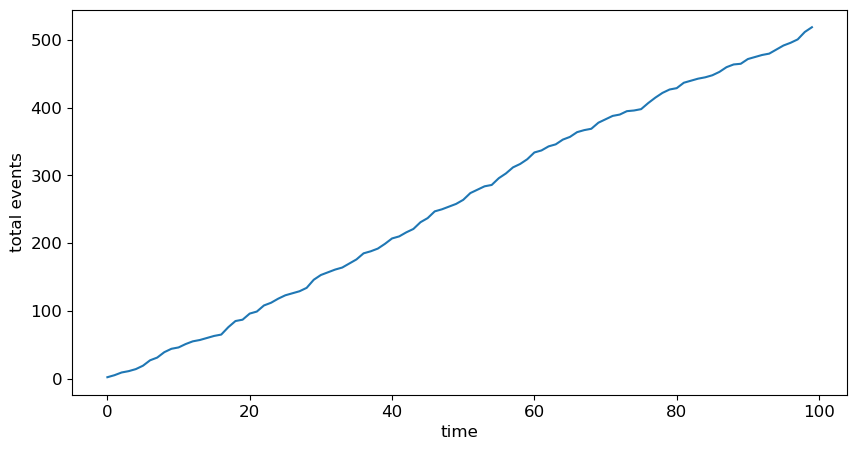

In [3]:
# rate 
lam = 5

# number of time intervals
T = 100

# simulate counts per interval
    #rvs(mu, loc=0, size=1, random_state=None)
events = poisson.rvs(mu=lam, size=T) # random variates 

# cumulative number of events
cumulative_events = np.cumsum(events)

plt.plot(cumulative_events)
plt.xlabel("time")
plt.ylabel("total events")
plt.show()

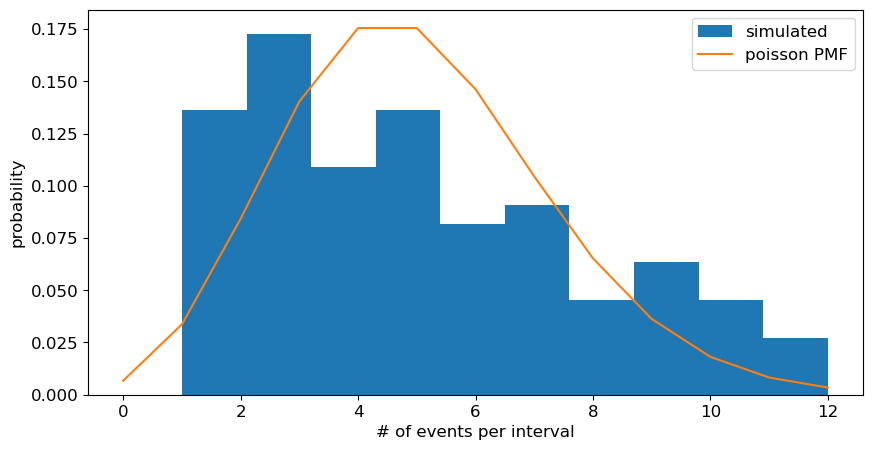

theoretical mean: 5.0
theoretical variance: 5.0
theoretical std: 2.23606797749979
theoretical median: 5.0


In [4]:
#looking at a probability mass function 
# possible event counts
k = np.arange(0, max(events)+1)

# theoretical PMF
pmf = poisson.pmf(k, mu=lam)

# histogram of simulated data
plt.hist(events, bins= 10, density=True, label="simulated")

# theoretical PMF
plt.plot(k, pmf, '-', label="poisson PMF")
plt.xlabel("# of events per interval")
plt.ylabel("probability")
plt.legend()
plt.show()

print("theoretical mean:", poisson.mean(mu=lam))
print("theoretical variance:", poisson.var(mu=lam))
print("theoretical std:", poisson.std(mu=lam))
print("theoretical median:", poisson.median(mu=lam))

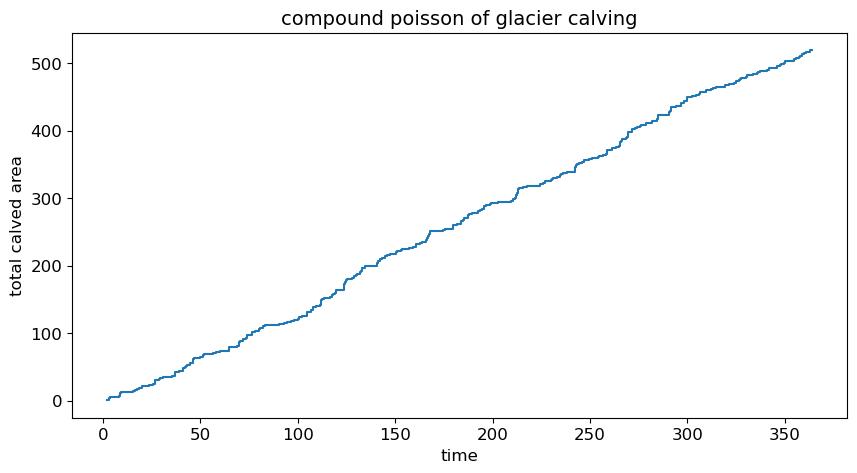

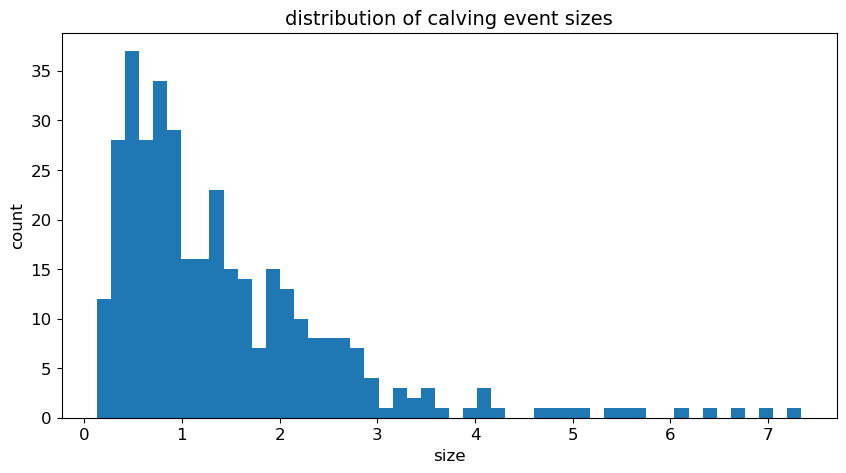

In [5]:
# so for glacial calving
#  if there is 1 event per day and we look at 365 days

L = 1 # event per day
T = 365 # days

# number of events 
N = np.random.poisson(L * T) #total number of calving events in a year

# event times - randomly distributed in the year
event_times = np.sort(np.random.uniform(0, T, N))

# glacier size
sizes = np.random.lognormal(mean=0, sigma=0.8, size = N)

# cumulative calved area
calved_area = np.cumsum(sizes)

plt.step(event_times, calved_area)
plt.xlabel("time")
plt.ylabel("total calved area")
plt.title("compound poisson of glacier calving")
plt.show()

plt.hist(sizes, bins=50)
plt.xlabel("size")
plt.ylabel("count")
plt.title("distribution of calving event sizes")
plt.show()

### 2. Poission statistics with Jakobshavn calving time series

We aim to characterize the statistical structure of the observed calving record by fitting a hierarchy of stochastic jump process models: 
1. Exponentially distributed event size and waiting times;

2. Gamma distributed event size and waiting times;

3. Time-varying sinusoidal processes; and 

4. A superposition of two distinct jump processes.


In [6]:
calving_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/Jakobshavn-Isbrae-CalvingStatistics/jakobshavn_calving_length_ts.csv"
df = pd.read_csv(calving_path, parse_dates=["Date"])

df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=["calving_magnitude"]).reset_index(drop=True)
df.head()

,Date,vel_up_centreline,dLdt,calving,calving_magnitude,dt_days,dt_years,Centerline_Length
0,2016-09-30,11906.565430,16967.250008,-5060.684578,-13.855399,12.0,0.032854,-231.317473
1,2016-10-06,11830.674805,16947.869027,-5117.194223,-14.010114,6.0,0.016427,47.086946
2,2016-10-12,12666.783203,-66053.938122,78720.721325,215.525589,6.0,0.016427,-1037.988013
3,2016-10-18,11279.811523,10971.578197,308.233326,0.843897,6.0,0.016427,-857.756749
4,2016-10-24,10976.319336,15959.660584,-4983.341248,-13.643645,6.0,0.016427,-595.585733


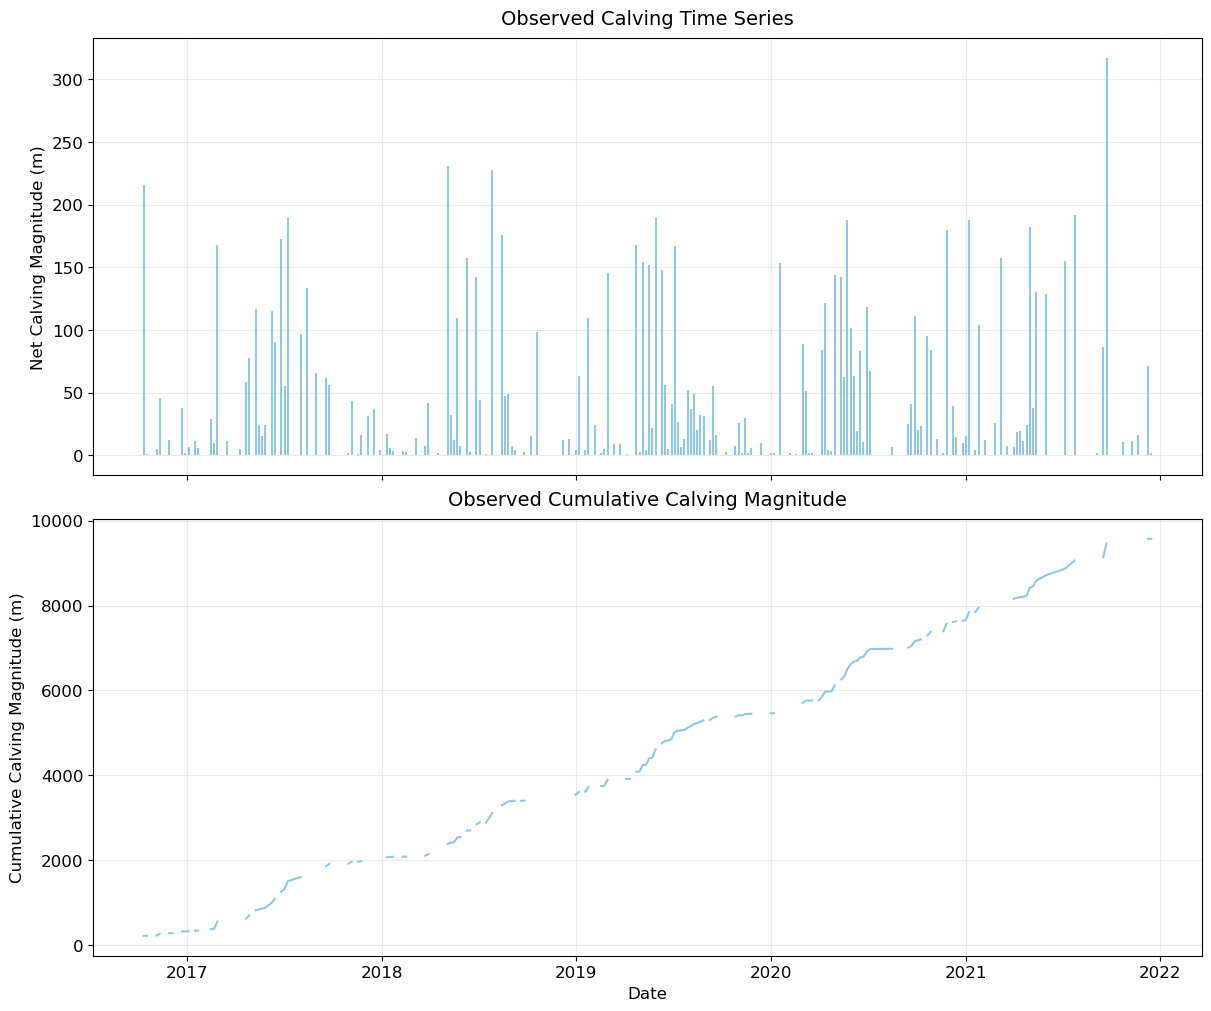

In [7]:

# mask negative values
df["calving_positive"] = df["calving_magnitude"].where(df["calving_magnitude"] > 0)

fig, axes = plt.subplots(2, 1, figsize = (12, 10), sharex=True, constrained_layout=True)

# calving time series
axes[0].vlines(df["Date"], ymin = 0, ymax = df["calving_positive"], color=light_blue)
axes[0].set_ylabel("Net Calving Magnitude (m)")
axes[0].set_title("Observed Calving Time Series", pad=10)
axes[0].grid(True, alpha=0.25)

# cumulative calved area
observed_calved_area = np.cumsum(df["calving_positive"])

axes[1].plot(df["Date"], observed_calved_area, color=light_blue)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Calving Magnitude (m)")
axes[1].set_title("Observed Cumulative Calving Magnitude", size = 14,  pad=10)
axes[1].grid(True, alpha=0.25)

plt.show()

In [8]:
print(len(df["calving_positive"]))

296


In [9]:
observed = df[["Date", "calving_positive"]].copy()
observed = observed[observed["calving_positive"] > 0]
observed["dt_days"] = observed["Date"].diff().dt.days

In [10]:
print(len(observed["calving_positive"]))

181


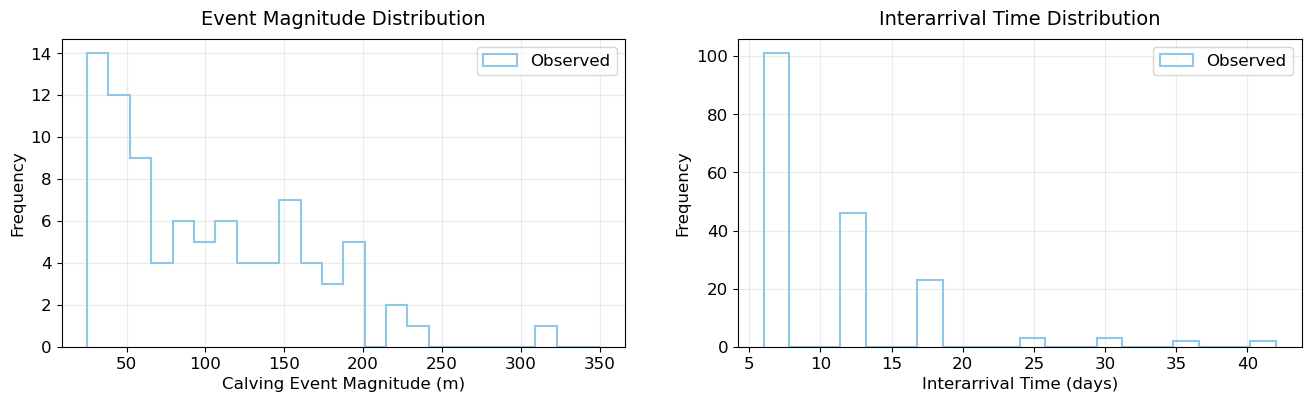

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].hist(
    observed["calving_positive"],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = light_blue,
    label = "Observed"
)

ax[0].set_xlabel("Calving Event Magnitude (m)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Event Magnitude Distribution", pad=10)
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].hist(
    observed["dt_days"].dropna(),
    bins=20,
    histtype="step",
    linewidth=1.5,
    color = light_blue,
    label="Observed"
)

ax[1].set_xlabel("Interarrival Time (days)")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Interarrival Time Distribution", pad=10)
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.show()

### 2a. Exponentially distributed event size and waiting times ###

In [12]:
def exp_calving(start_date, end_date, time_scale, size_scale, seed=None):
    """ exponential waiting times and exponential event sizes """
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    event_times = []
    event_sizes = []

    while current_time < end_date:
        # event_time generation
        #wait_days = time_loc + rng.exponential(scale=time_scale)
        wait_days = rng.exponential(scale = time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

            # event_size generation 
            size = rng.exponential(scale=size_scale)
            event_sizes.append(size)

    return pd.DataFrame({"Date": pd.to_datetime(event_times), "synthetic_calving": event_sizes})

In [13]:
from scipy.stats import expon
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html

# expon.fit() returns two parameters: loc and scale.
# loc = location parameter - this shifts (L-R) the distribution 
# scale = scale parameter - equivalent to the mean of the data 

exp_event_sizes = observed["calving_positive"].dropna()
exp_event_sizes = exp_event_sizes[exp_event_sizes > 0]

exp_event_times = observed["dt_days"].dropna()
exp_event_times = exp_event_times[exp_event_times > 0]

time_loc, time_exp = expon.fit(exp_event_times, floc=0)
size_loc, size_exp = expon.fit(exp_event_sizes, floc=0)

time_exp = float(time_exp)
size_exp = float(size_exp)

print("time loc:", time_loc, "time scale:", time_exp)
print("size loc:", size_loc, "size scale:", size_exp)


time loc: 0.0 time scale: 10.5
size loc: 0.0 size scale: 52.89900299670455


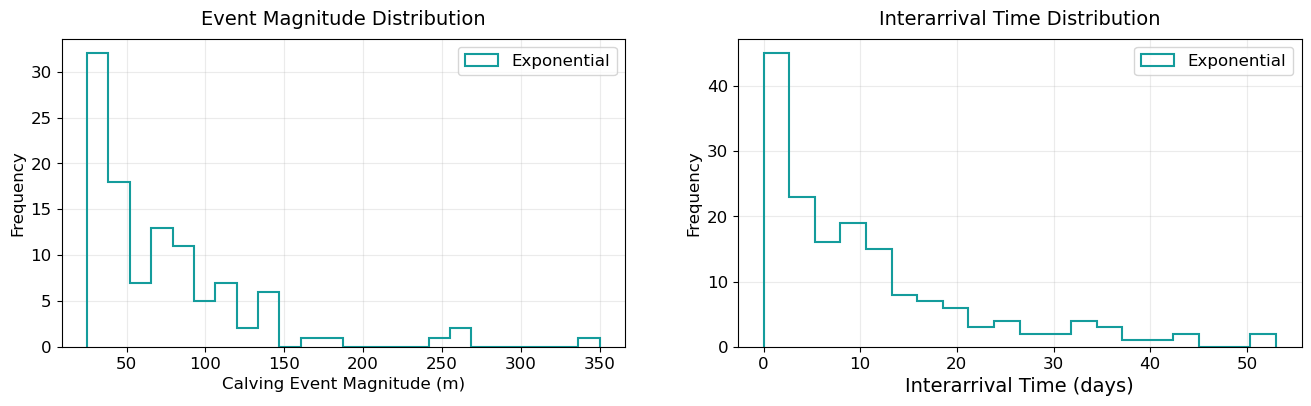

In [14]:
synthetic_exp = exp_calving(
    start_date=observed["Date"].min(),
    end_date=observed["Date"].max(),
    time_scale=time_exp,
    size_scale=size_exp,
    seed=36
)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

# exponential distribution of event sizes and waiting times
ax[0].hist(
    synthetic_exp["synthetic_calving"],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = teal,
    label = "Exponential"
)

ax[0].set_xlabel("Calving Event Magnitude (m)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Event Magnitude Distribution", pad=10)
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].hist(
    synthetic_exp["Date"].diff().dt.days.dropna(),
    bins=20,
    histtype="step",
    linewidth=1.5,
    color = teal,
    label="Exponential"
)

ax[1].set_xlabel("Interarrival Time (days)", fontsize=14)
ax[1].set_ylabel("Frequency")
ax[1].set_title("Interarrival Time Distribution", pad=10)
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.show()



In [15]:
print(len(synthetic_exp["synthetic_calving"]))

164


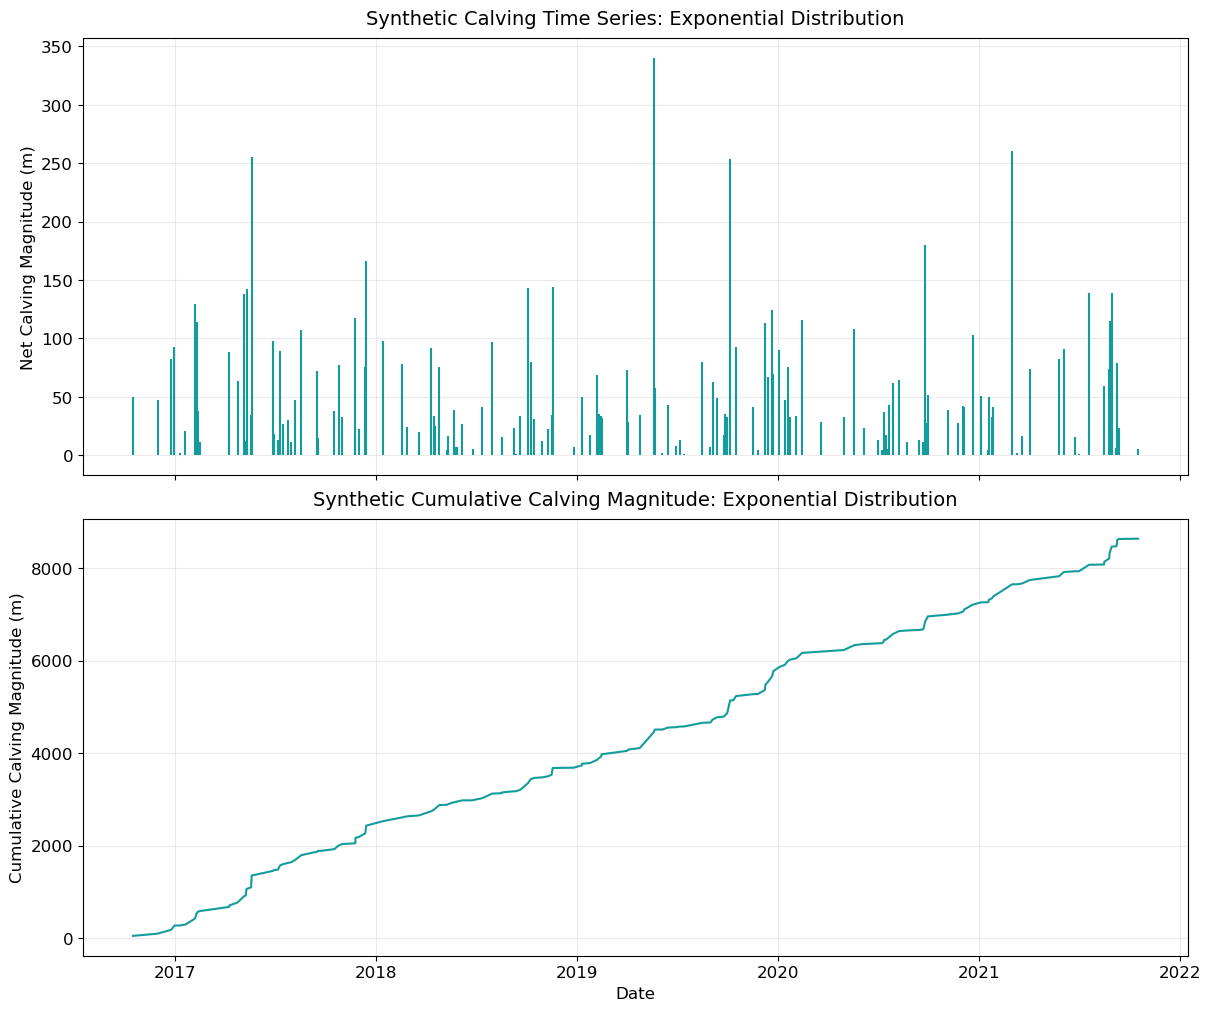

In [16]:
# mask negative values
#synthetic_exp["synthetic_calving"] = synthetic_exp["synthetic_calving"].where(synthetic_exp["synthetic_calving"] > 0)

fig, axes = plt.subplots(2, 1, figsize = (12, 10), sharex=True, constrained_layout=True)

#synthetic (exponential) calving time series
axes[0].vlines(synthetic_exp["Date"], ymin = 0, ymax = synthetic_exp["synthetic_calving"], color=teal)
axes[0].set_ylabel("Net Calving Magnitude (m)")
axes[0].set_title("Synthetic Calving Time Series: Exponential Distribution", pad = 10)
axes[0].grid(True, alpha=0.25)

#synthetic (expontential) calving cumulative area
exponential_calved_area = np.cumsum(synthetic_exp["synthetic_calving"])

axes[1].plot(synthetic_exp["Date"], exponential_calved_area, color=teal)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Calving Magnitude (m)")
axes[1].set_title("Synthetic Cumulative Calving Magnitude: Exponential Distribution", pad = 10)
axes[1].grid(True, alpha=0.25)

plt.show()

In [17]:
print(len(synthetic_exp["synthetic_calving"]))

164


### 2b. Gamma distributed event size and waiting times ###

Gamma distributions have a shape parameter - determining the shape of the distribution, and a scale parameter (also known as a rate parameter) that can "shrink" or "compress" a distribution. 

In [18]:
def gamma_calving(start_date, end_date, time_shape, time_scale, size_shape, size_scale, seed=None):
    """gamma-distributed waiting times and gamma-distributed event sizes."""
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    event_times = []
    event_sizes = []

    while current_time < end_date:
        # event_time generation
        #wait_days = time_loc +rng.gamma(shape=time_shape, scale=time_scale)
        wait_days = rng.gamma(shape=time_shape, scale=time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

            # event_size generation
            size = rng.gamma(shape=size_shape, scale=size_scale)
            event_sizes.append(size)

    return pd.DataFrame({"Date": pd.to_datetime(event_times), "synthetic_calving": event_sizes})

In [19]:
from scipy.stats import gamma
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html

# gamma.fit() returns three parameters: shape, loc, and scale.
# shape = shape parameter - determines the shape of the distribution
# loc = location parameter - this shifts (L-R) the distribution
# scale = scale parameter - can "shrink" or "compress" a distribution

gamma_event_sizes = observed["calving_positive"].dropna()
gamma_event_sizes = gamma_event_sizes[gamma_event_sizes > 0]

gamma_event_times = observed["dt_days"].dropna()
gamma_event_times = gamma_event_times[gamma_event_times > 0]

time_shape, time_loc, time_scale = gamma.fit(gamma_event_times, floc=0)
size_shape, size_loc, size_scale = gamma.fit(gamma_event_sizes, floc=0)

time_shape = float(time_shape)
time_scale = float(time_scale)
size_shape = float(size_shape)
size_scale = float(size_scale)

print("time shape:", time_shape, "time loc:", time_loc, "time scale:", time_scale)
print("size shape:", size_shape, "size loc:", size_loc, "size scale:", size_scale)

time shape: 3.4769734766603397 time loc: 0 time scale: 3.0198677299331407
size shape: 0.6062186495707996 size loc: 0 size scale: 87.26059984158658


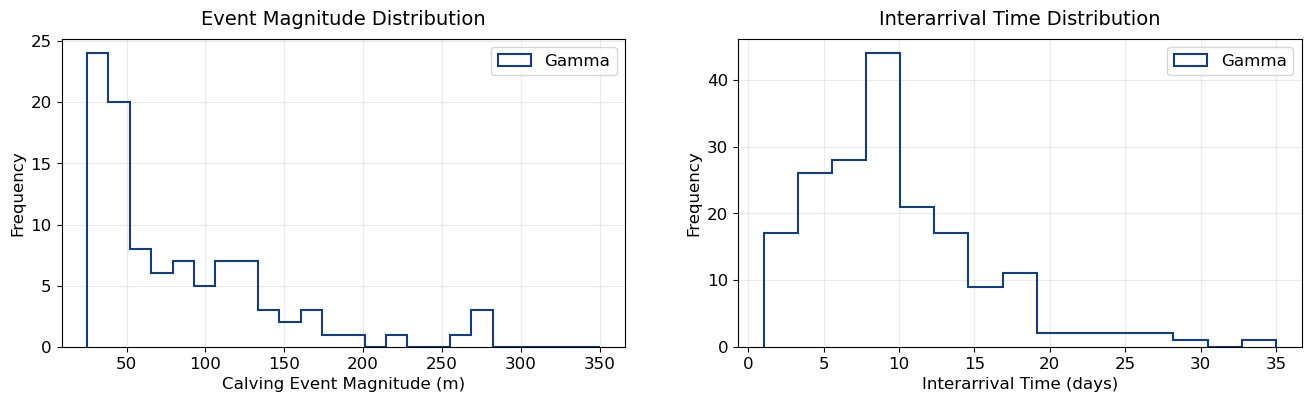

In [20]:
synthetic_gamma = gamma_calving(
    start_date=observed["Date"].min(),
    end_date=observed["Date"].max(),
    time_shape=time_shape,
    time_scale=time_scale,
    size_shape=size_shape,
    size_scale=size_scale,
    seed=42
)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
# gamma distribution of event sizes and waiting times

ax[0].hist(
    synthetic_gamma["synthetic_calving"],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = dark_blue,
    label = "Gamma"
)

ax[0].set_xlabel("Calving Event Magnitude (m)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Event Magnitude Distribution", pad=10)
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].hist(
    synthetic_gamma["Date"].diff().dt.days.dropna(),
    bins=15,
    histtype="step",
    linewidth=1.5,
    color = dark_blue,
    label="Gamma"
)

ax[1].set_xlabel("Interarrival Time (days)")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Interarrival Time Distribution", pad=10)
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.show()


In [21]:
print(len(synthetic_gamma["synthetic_calving"]))

184


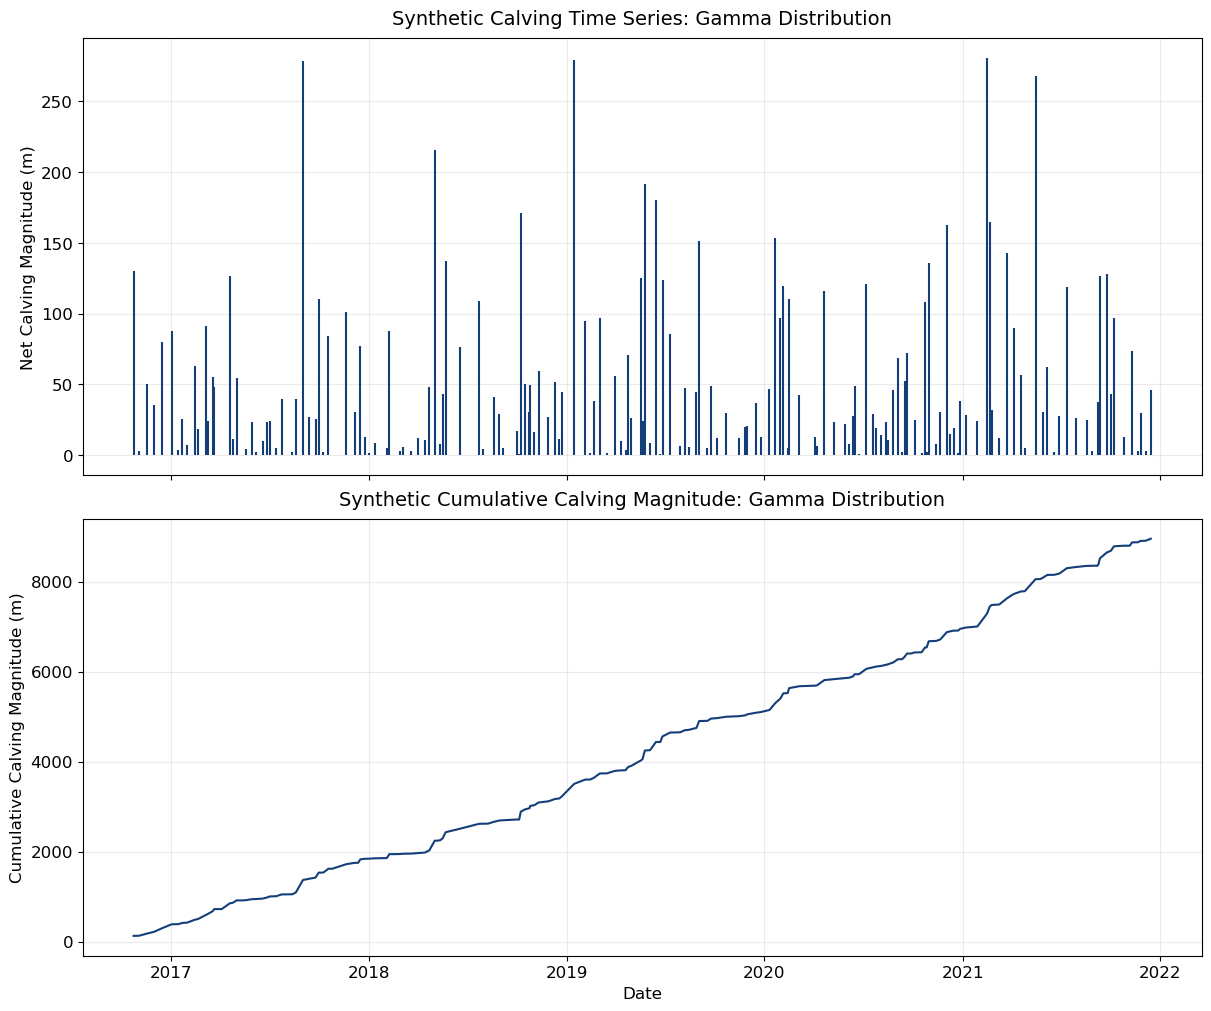

In [22]:

fig, axes = plt.subplots(2, 1, figsize = (12, 10), sharex=True, constrained_layout=True)

# synthetic (gamma) calving time series
axes[0].vlines(synthetic_gamma["Date"], ymin=0, ymax=synthetic_gamma["synthetic_calving"], color=dark_blue)
axes[0].set_ylabel("Net Calving Magnitude (m)")
axes[0].set_title("Synthetic Calving Time Series: Gamma Distribution", pad=10)
axes[0].grid(True, alpha=0.25)

# synthetic (gamma) calving cumulative area
gamma_calved_area = np.cumsum(synthetic_gamma["synthetic_calving"])

axes[1].plot(synthetic_gamma["Date"], gamma_calved_area, color=dark_blue)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Calving Magnitude (m)")
axes[1].set_title("Synthetic Cumulative Calving Magnitude: Gamma Distribution", pad=10)
axes[1].grid(True, alpha=0.25)

plt.show()

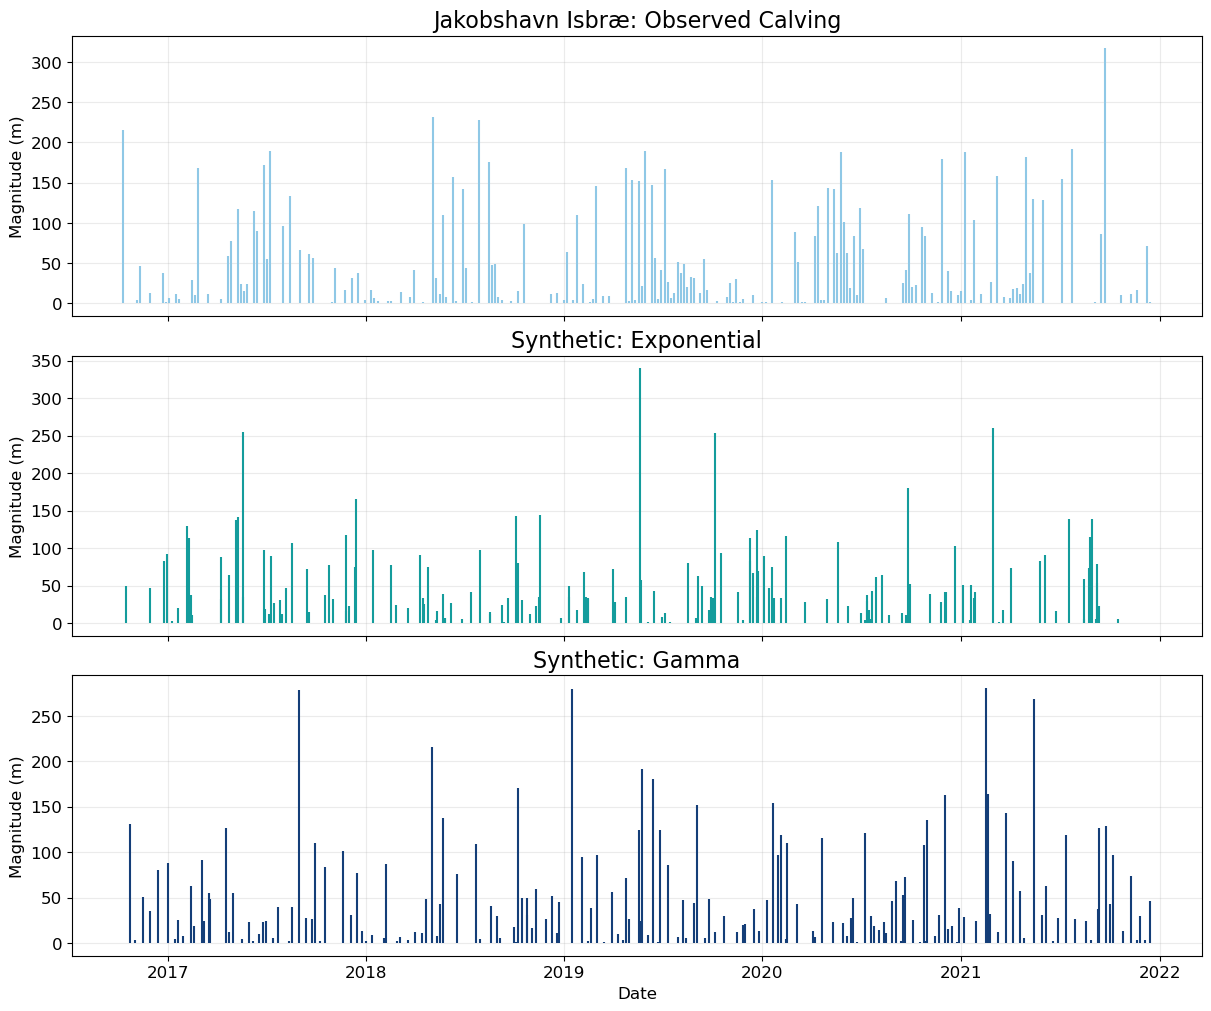

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

#observed calving
axes[0].vlines(observed["Date"], ymin=0, ymax=observed["calving_positive"], color=light_blue)
axes[0].set_title("Jakobshavn Isbræ: Observed Calving", fontsize=16)
axes[0].set_ylabel("Magnitude (m)")
axes[0].grid(True, alpha=0.25)


#synthetic exp
synthetic_exp["synthetic_calving"] = synthetic_exp["synthetic_calving"].where(synthetic_exp["synthetic_calving"] > 0)

axes[1].vlines(synthetic_exp["Date"],ymin=0,ymax=synthetic_exp["synthetic_calving"],color=teal)
axes[1].set_title("Synthetic: Exponential", fontsize=16)
axes[1].set_ylabel("Magnitude (m)")
axes[1].grid(True, alpha=0.25)


# synthetic gamma
synthetic_gamma["synthetic_calving"] = synthetic_gamma["synthetic_calving"].where(synthetic_gamma["synthetic_calving"] > 0)

axes[2].vlines(synthetic_gamma["Date"],ymin=0,ymax=synthetic_gamma["synthetic_calving"],color=dark_blue)
axes[2].set_title("Synthetic: Gamma", fontsize=16)
axes[2].set_ylabel("Magnitude (m)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.25)


for ax in axes:
    ax.tick_params(axis='both', labelsize=12)

plt.show()

In [24]:
#observed_cumulative_v= terminus_plot.dropna(subset=["calving_positive"]).copy()
observed_cumulative = observed["calving_positive"].cumsum()

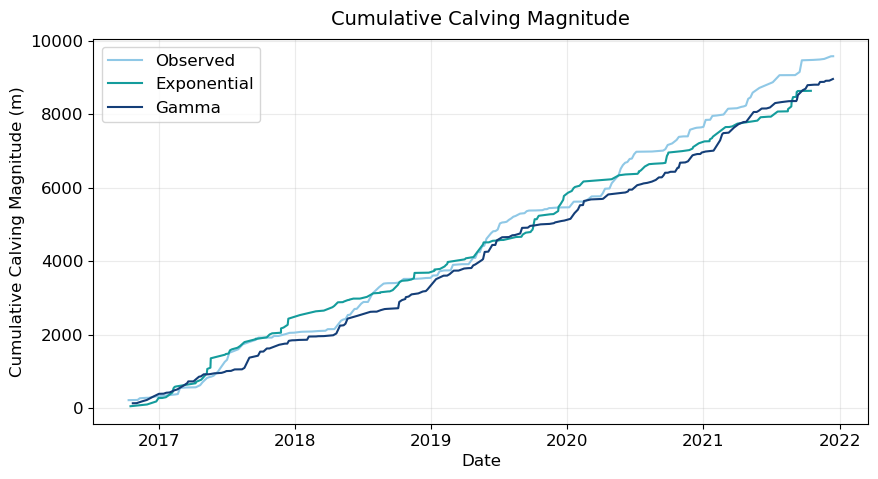

In [25]:
plt.plot(observed["Date"], observed_cumulative, color=light_blue)
plt.plot(synthetic_exp["Date"], exponential_calved_area, color=teal)
plt.plot(synthetic_gamma["Date"], gamma_calved_area, color=dark_blue)
plt.xlabel("Date")
plt.ylabel("Cumulative Calving Magnitude (m)")
plt.title("Cumulative Calving Magnitude", pad=10)
plt.grid(True, alpha=0.25)
plt.legend(["Observed", "Exponential", "Gamma"])
plt.show()  

In [26]:
# #residual = observed - model/synehtic

# residual_exp = observed_cumulative_v["observed_cumulative"] - exponential_calved_area
# residual_gamma = observed_cumulative_v["observed_cumulative"] - gamma_calved_area


# plt.figure(figsize=(8,5))

# plt.plot(
#     observed_cumulative_v["Date"],
#     residual_exp,
#     color=teal,
#     label="Observed - Exponential"
# )

# plt.plot(
#     observed_cumulative_v["Date"],
#     residual_gamma,
#     color=dark_blue,
#     label="Observed - Gamma"
# )

# plt.axhline(0, color="black", linestyle="--", alpha=0.5)

# plt.xlabel("Date")
# plt.ylabel("Residual (m)")
# plt.title("Residuals Between Observed and Synthetic Cumulative Calving")

# plt.grid(True, alpha=0.25)
# plt.legend()

# plt.show()

### 2c. Combining exponential AND gamma distributions
(I) Exponential distributed event size, gamma distributed waiting times



In [27]:
def exp_gamma_calving(start_date, end_date, time_shape, time_scale, size_scale, seed = None):
    """ Exponentially distributed event size, gamma distributed waiting times """
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    event_times = []
    event_sizes = []

    while current_time < end_date:
        # event_time generation
        wait_days = rng.gamma(shape=time_shape, scale=time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

            # event_size generation 
            size = rng.exponential(scale=size_scale)
            event_sizes.append(size)

    return pd.DataFrame({"Date": pd.to_datetime(event_times), "synthetic_calving": event_sizes})

In [28]:
exp_event_sizes_I = observed["calving_positive"].dropna()
exp_event_sizes_I = exp_event_sizes_I[exp_event_sizes_I > 0]

gamma_event_times_I = observed["dt_days"].dropna()
gamma_event_times_I = gamma_event_times_I[gamma_event_times_I > 0]

time_shape_I, time_loc_I, time_scale_I = gamma.fit(gamma_event_times_I, floc=0)
size_loc_I, size_exp_I = expon.fit(exp_event_sizes_I, floc=0)

time_shape_I = float(time_shape_I)
time_scale_I = float(time_scale_I)
size_exp_I = float(size_exp_I)

print("time shape:", time_shape_I, "time loc:", time_loc_I, "time scale:", time_scale_I)
print("size loc:", size_loc_I, "size scale:", size_exp_I)

time shape: 3.4769734766603397 time loc: 0 time scale: 3.0198677299331407
size loc: 0.0 size scale: 52.89900299670455


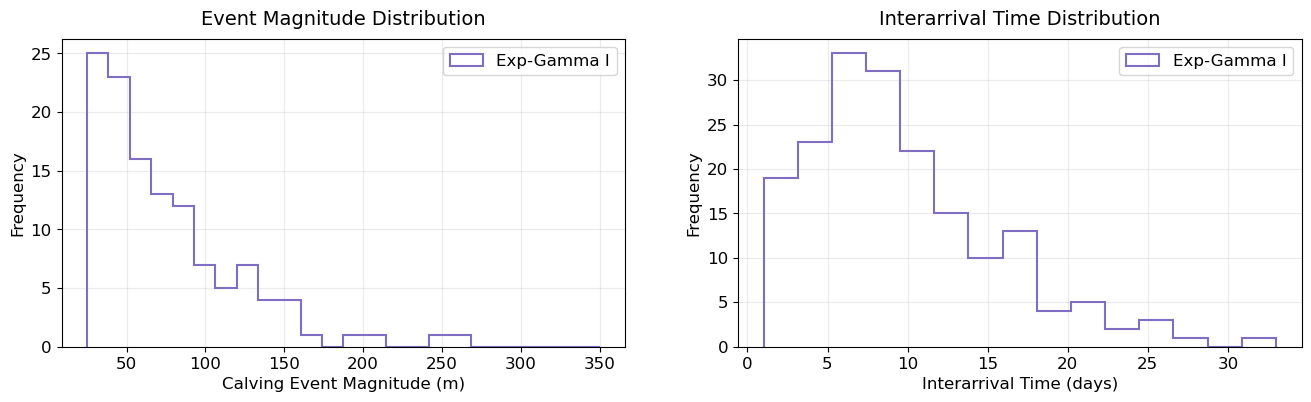

In [29]:
synthetic_exp_gamma_I = exp_gamma_calving(
    start_date=observed["Date"].min(),
    end_date=observed["Date"].max(),
    time_shape=time_shape_I,
    time_scale=time_scale_I,
    size_scale=size_exp_I,
    seed=24
)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
# exponential event sizes, gamma waiting times

ax[0].hist(
    synthetic_exp_gamma_I["synthetic_calving"],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = light_purple,
    label = "Exp-Gamma I"
)
ax[0].set_xlabel("Calving Event Magnitude (m)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Event Magnitude Distribution", pad=10)
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].hist(
    synthetic_exp_gamma_I["Date"].diff().dt.days.dropna(),
    bins=15,
    histtype="step",
    linewidth=1.5,
    color = light_purple,
    label="Exp-Gamma I"
)

ax[1].set_xlabel("Interarrival Time (days)")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Interarrival Time Distribution", pad=10)
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.show()

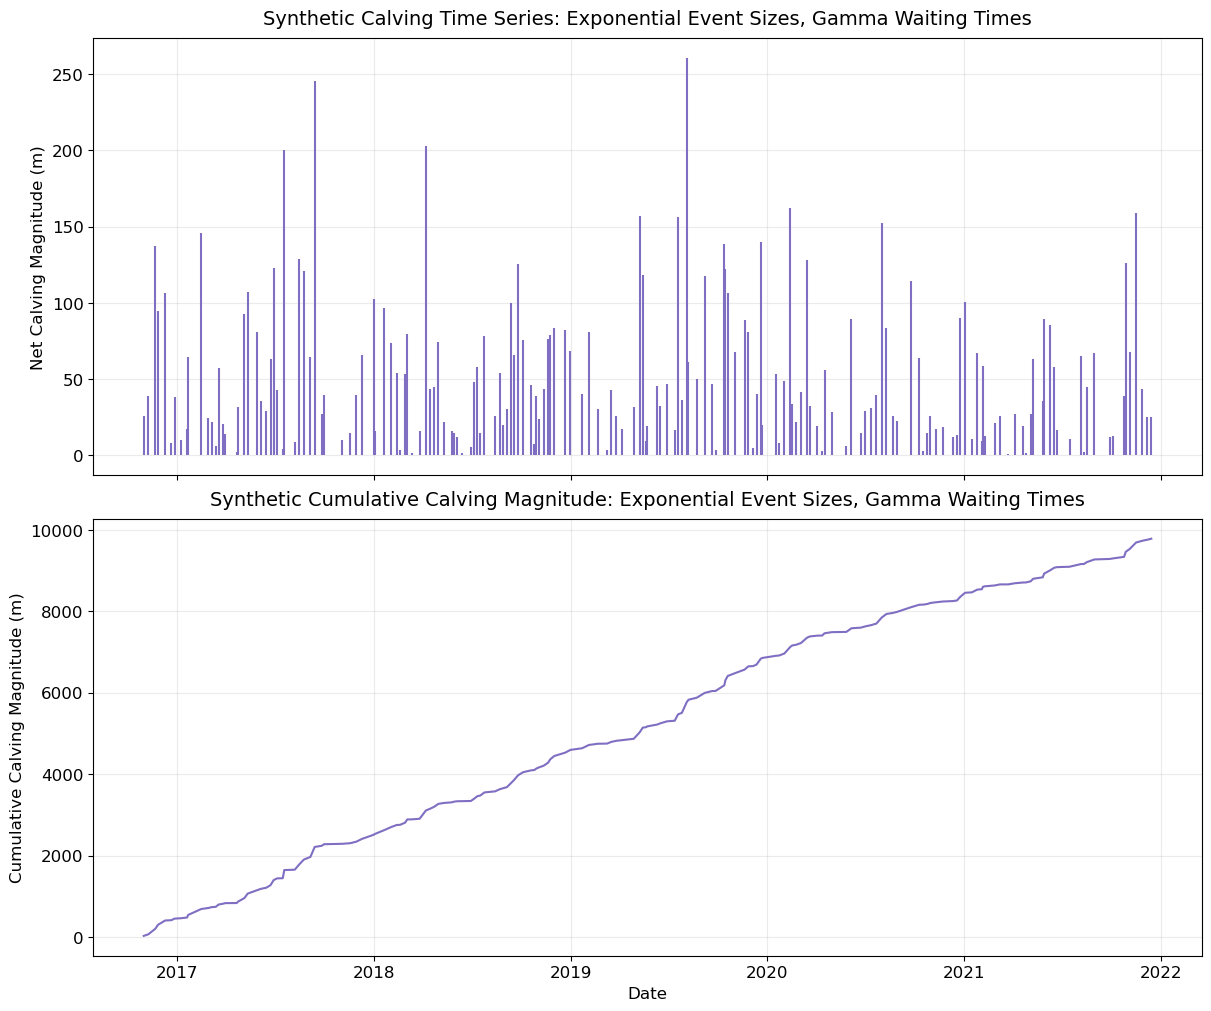

In [30]:
fig, axes = plt.subplots(2, 1, figsize = (12, 10), sharex=True, constrained_layout=True)

# synthetic exp-gamma I calving time series
axes[0].vlines(synthetic_exp_gamma_I["Date"], ymin=0, ymax=synthetic_exp_gamma_I["synthetic_calving"], color=light_purple)
axes[0].set_ylabel("Net Calving Magnitude (m)")
axes[0].set_title("Synthetic Calving Time Series: Exponential Event Sizes, Gamma Waiting Times", pad=10)
axes[0].grid(True, alpha=0.25)  

# synthetic exp-gamma I calving cumulative area
exp_gamma_I_calved_area = np.cumsum(synthetic_exp_gamma_I["synthetic_calving"])
axes[1].plot(synthetic_exp_gamma_I["Date"], exp_gamma_I_calved_area, color=light_purple)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Calving Magnitude (m)")
axes[1].set_title("Synthetic Cumulative Calving Magnitude: Exponential Event Sizes, Gamma Waiting Times", pad=10)
axes[1].grid(True, alpha=0.25)
plt.show()

(II) Gamma distributed event size, exponential distributed waiting times

In [31]:
def gamma_exp_calving(start_date, end_date, time_scale, size_shape, size_scale, seed=None):
    """Gamma-distributed event sizes and exponentially distributed waiting times."""
    
    rng = np.random.default_rng(seed)

    current_time = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    event_times = []
    event_sizes = []

    while current_time < end_date:

        # event time generation (exponential)
        wait_days = rng.exponential(scale=time_scale)
        current_time += pd.Timedelta(days=wait_days)

        if current_time < end_date:
            event_times.append(current_time)

            # event size generation (gamma)
            size = rng.gamma(shape=size_shape, scale=size_scale)
            event_sizes.append(size)

    return pd.DataFrame({
        "Date": pd.to_datetime(event_times),
        "synthetic_calving": event_sizes
    })

In [32]:
gamma_event_sizes_II = observed["calving_positive"].dropna()
gamma_event_sizes_II = gamma_event_sizes_II[gamma_event_sizes_II > 0] 

exp_event_times_II = observed["dt_days"].dropna()
exp_event_times_II = exp_event_times_II[exp_event_times_II > 0]

time_loc_II, time_exp_II = expon.fit(exp_event_times_II, floc=0)
size_shape_II, size_loc_II, size_scale_II = gamma.fit(gamma_event_sizes_II, floc=0)

time_exp_II = float(time_exp_II)
size_shape_II = float(size_shape_II)
size_scale_II = float(size_scale_II)

print("time loc:", time_loc_II, "time scale:", time_exp_II)
print("size shape:", size_shape_II, "size loc:", size_loc_II, "size scale:", size_scale_II)

time loc: 0.0 time scale: 10.5
size shape: 0.6062186495707996 size loc: 0 size scale: 87.26059984158658


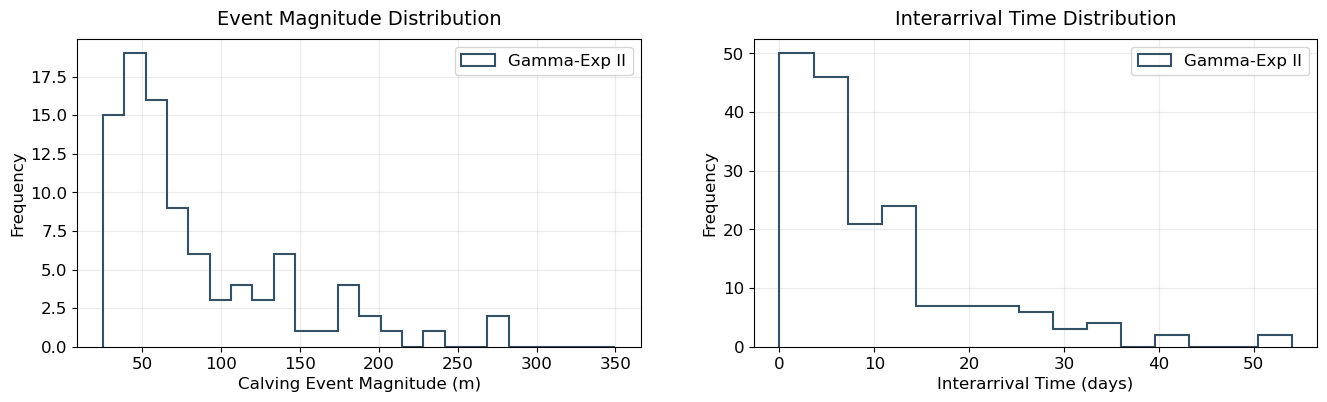

In [33]:
synthetic_gamma_exp_II = gamma_exp_calving(
    start_date=observed["Date"].min(),
    end_date=observed["Date"].max(),
    time_scale=time_exp_II,
    size_shape=size_shape_II,
    size_scale=size_scale_II,
    seed=24
)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
# gamma event sizes, exponential waiting times
ax[0].hist(
    synthetic_gamma_exp_II["synthetic_calving"],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = blue_2,
    label = "Gamma-Exp II"
)
ax[0].set_xlabel("Calving Event Magnitude (m)")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Event Magnitude Distribution", pad=10)
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].hist(
    synthetic_gamma_exp_II["Date"].diff().dt.days.dropna(),
    bins=15,
    histtype="step",
    linewidth=1.5,
    color = blue_2,
    label="Gamma-Exp II"
)

ax[1].set_xlabel("Interarrival Time (days)")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Interarrival Time Distribution", pad=10)
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.show()

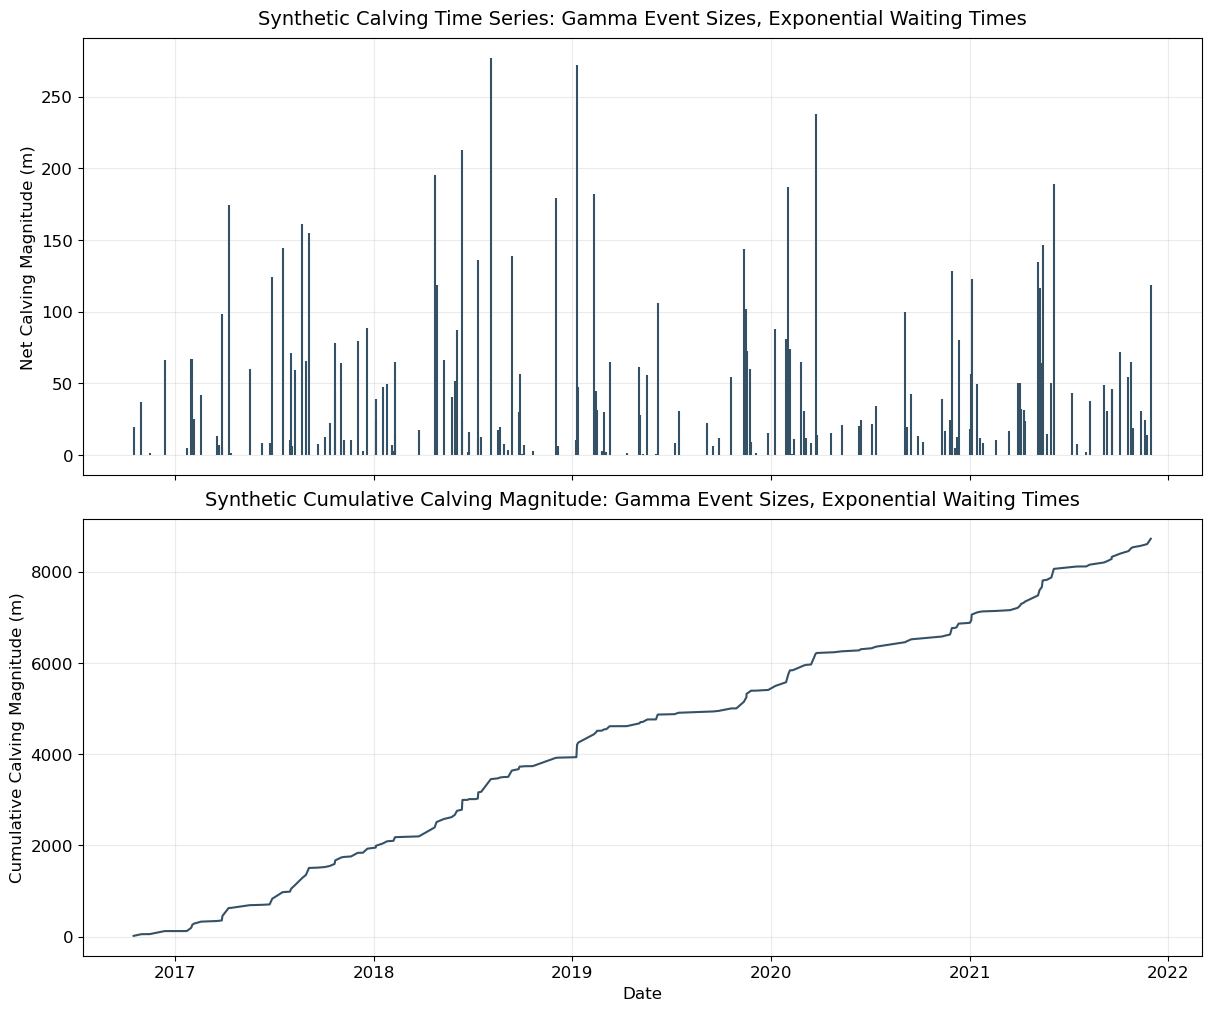

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

# sytheitc gamma-exp II calving time series
axes[0].vlines(synthetic_gamma_exp_II["Date"], ymin=0, ymax=synthetic_gamma_exp_II["synthetic_calving"], color=blue_2)
axes[0].set_ylabel("Net Calving Magnitude (m)")
axes[0].set_title("Synthetic Calving Time Series: Gamma Event Sizes, Exponential Waiting Times", pad=10)
axes[0].grid(True, alpha=0.25)  

# synthetic gamma-exp II calving cumulative area
gamma_exp_II_calved_area = np.cumsum(synthetic_gamma_exp_II["synthetic_calving"])
axes[1].plot(synthetic_gamma_exp_II["Date"], gamma_exp_II_calved_area, color=blue_2)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Calving Magnitude (m)")
axes[1].set_title("Synthetic Cumulative Calving Magnitude: Gamma Event Sizes, Exponential Waiting Times", pad=10)
axes[1].grid(True, alpha=0.25)
plt.show()

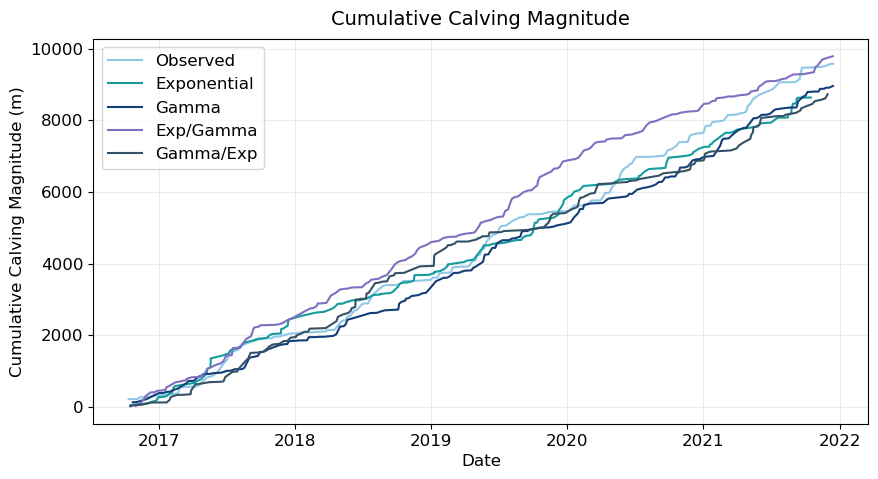

In [35]:
plt.plot(observed["Date"], observed_cumulative, color=light_blue)
plt.plot(synthetic_exp["Date"], exponential_calved_area, color=teal)
plt.plot(synthetic_gamma["Date"], gamma_calved_area, color=dark_blue)
plt.plot(synthetic_exp_gamma_I["Date"], exp_gamma_I_calved_area, color=light_purple)
plt.plot(synthetic_gamma_exp_II["Date"], gamma_exp_II_calved_area, color=blue_2)
plt.xlabel("Date")
plt.ylabel("Cumulative Calving Magnitude (m)")
plt.title("Cumulative Calving Magnitude", pad=10)
plt.grid(True, alpha=0.25)
plt.legend(["Observed", "Exponential", "Gamma", "Exp/Gamma", "Gamma/Exp"])
plt.show()

In [36]:
observed_total = observed["calving_positive"].sum()
exp_total = synthetic_exp["synthetic_calving"].sum()
gamma_total = synthetic_gamma["synthetic_calving"].sum()
exp_gamma_I_total = synthetic_exp_gamma_I["synthetic_calving"].sum()
gamma_exp_II_total = synthetic_gamma_exp_II["synthetic_calving"].sum()

print("Total Observed Calving:", observed_total, "m")
print("Total Synthetic Calving (Exponential):", exp_total, "m")
print("Total Synthetic Calving (Gamma):", gamma_total, "m")
print("Total Synthetic Calving (Exp/Gamma):", exp_gamma_I_total, "m")
print("Total Synthetic Calving (Gamma/Exp):", gamma_exp_II_total, "m")

Total Observed Calving: 9574.719542403524 m
Total Synthetic Calving (Exponential): 8633.084498914664 m
Total Synthetic Calving (Gamma): 8955.518571269264 m
Total Synthetic Calving (Exp/Gamma): 9785.690141082872 m
Total Synthetic Calving (Gamma/Exp): 8723.31117089428 m


### 3a. Binning the synthetic data into the observation intervals
If I sample the theoretical data at the time interval for the observations, does the total amount of calving in that interval look like the observations?

In [37]:

#https://docs.xarray.dev/en/latest/generated/xarray.DataArray.groupby_bins.html


bin_edges = observed["Date"].sort_values().values
interval_dates = observed["Date"].sort_values().iloc[1:].reset_index(drop=True)

#synthetic exp
synthetic_exp_da = xr.DataArray(synthetic_exp["synthetic_calving"].values,coords={"Date": synthetic_exp["Date"].values},dims="Date")
synthetic_exp_binned = synthetic_exp_da.groupby_bins("Date",bins=bin_edges).sum()
synthetic_exp_intervals = pd.DataFrame({"Date": interval_dates,"calving": synthetic_exp_binned.values})
synthetic_exp_intervals["calving"] = (synthetic_exp_intervals["calving"].fillna(0))
synthetic_exp_intervals["cumulative"] = synthetic_exp_intervals["calving"].cumsum()

#gamma exp
synthetic_gamma_da = xr.DataArray(synthetic_gamma["synthetic_calving"].values,coords={"Date": synthetic_gamma["Date"].values},dims="Date")
synthetic_gamma_binned = synthetic_gamma_da.groupby_bins("Date",bins=bin_edges).sum()
synthetic_gamma_intervals = pd.DataFrame({"Date": interval_dates,"calving": synthetic_gamma_binned.values})
synthetic_gamma_intervals["calving"] = (synthetic_gamma_intervals["calving"].fillna(0))
synthetic_gamma_intervals["cumulative"] = synthetic_gamma_intervals["calving"].cumsum()

#exp  / gamma
synthetic_exp_gamma_I_da = xr.DataArray(synthetic_exp_gamma_I["synthetic_calving"].values,coords={"Date": synthetic_exp_gamma_I["Date"].values},dims="Date")
synthetic_exp_gamma_I_binned = synthetic_exp_gamma_I_da.groupby_bins("Date",bins=bin_edges).sum()
synthetic_exp_gamma_I_intervals = pd.DataFrame({"Date": interval_dates,"calving": synthetic_exp_gamma_I_binned.values})
synthetic_exp_gamma_I_intervals["calving"] = (synthetic_exp_gamma_I_intervals["calving"].fillna(0))
synthetic_exp_gamma_I_intervals["cumulative"] = synthetic_exp_gamma_I_intervals["calving"].cumsum()

#gamma / exp
synthetic_gamma_exp_II_da = xr.DataArray(synthetic_gamma_exp_II["synthetic_calving"].values,coords={"Date": synthetic_gamma_exp_II["Date"].values},dims="Date")
synthetic_gamma_exp_II_binned = synthetic_gamma_exp_II_da.groupby_bins("Date",bins=bin_edges).sum()
synthetic_gamma_exp_II_intervals = pd.DataFrame({"Date": interval_dates,"calving": synthetic_gamma_exp_II_binned.values})
synthetic_gamma_exp_II_intervals["calving"] = (synthetic_gamma_exp_II_intervals["calving"].fillna(0))
synthetic_gamma_exp_II_intervals["cumulative"] = synthetic_gamma_exp_II_intervals["calving"].cumsum()

observed_sorted = observed.sort_values("Date").reset_index(drop=True)
observed_interval = xr.DataArray(observed_sorted["calving_positive"].iloc[1:].values,coords={"Date": observed_sorted["Date"].iloc[1:].values},dims="Date",name="observed_calving")
observed_interval = observed_interval.fillna(0)
observed_interval_cumulative = observed_interval.cumsum(dim="Date")

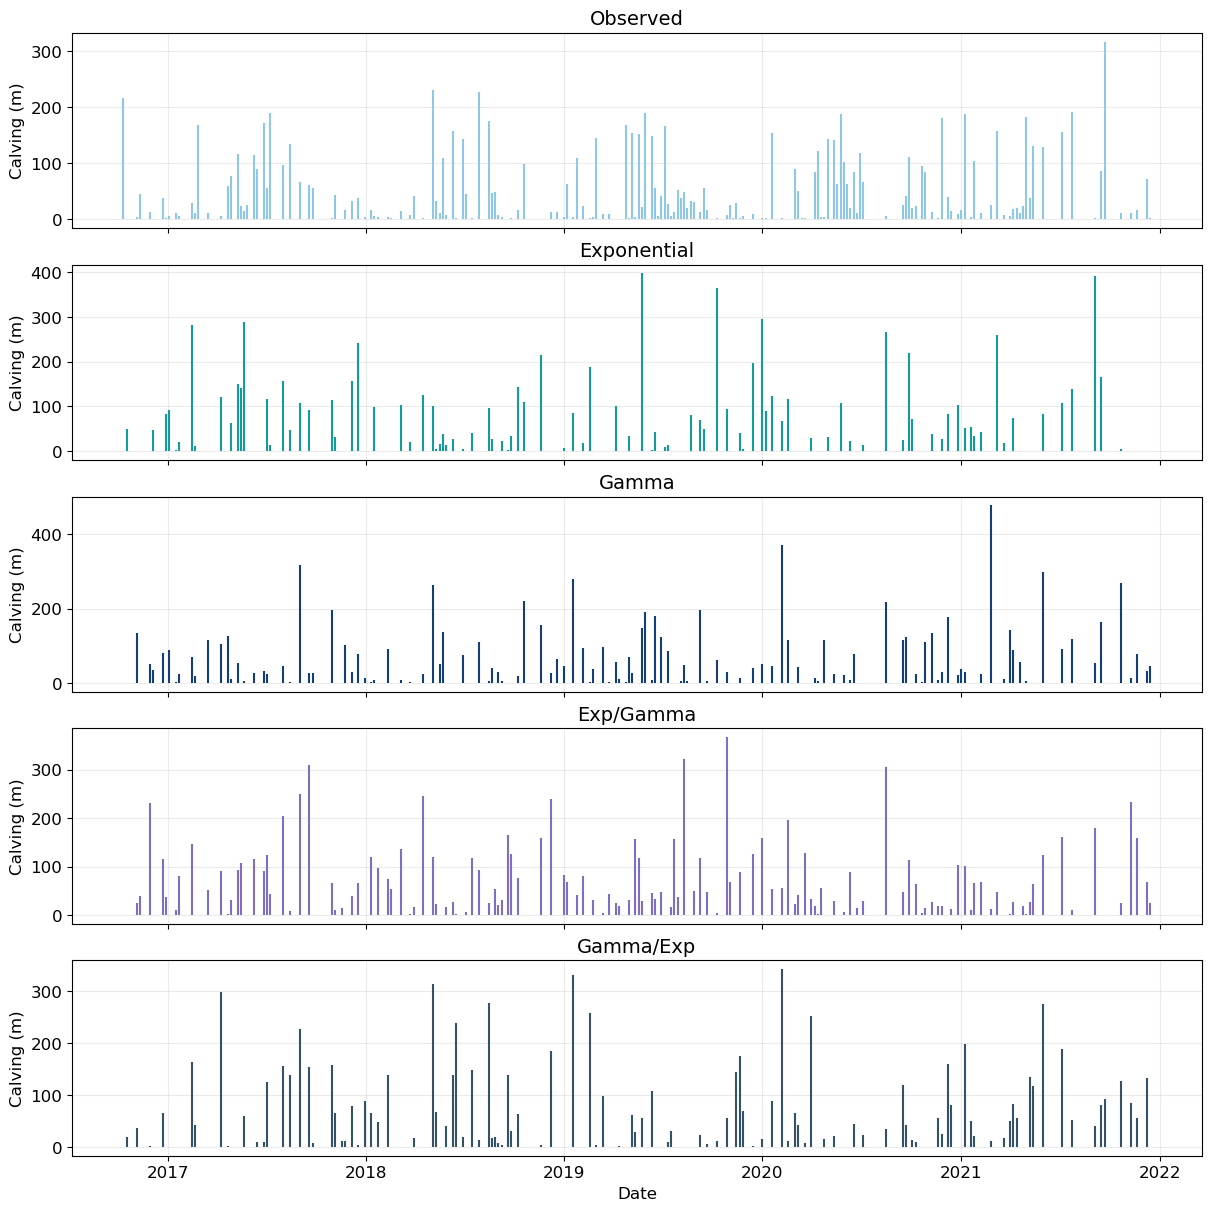

In [38]:
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True, constrained_layout=True)

# observed
axes[0].vlines(
    observed["Date"],
    ymin=0,
    ymax=observed["calving_positive"],
    color=light_blue
)
axes[0].set_title("Observed")

# exponential
axes[1].vlines(
    synthetic_exp_intervals["Date"],
    ymin=0,
    ymax=synthetic_exp_intervals["calving"],
    color=teal
)
axes[1].set_title("Exponential")

# gamma
axes[2].vlines(
    synthetic_gamma_intervals["Date"],
    ymin=0,
    ymax=synthetic_gamma_intervals["calving"],
    color=dark_blue
)
axes[2].set_title("Gamma")

# exp wait + gamma size
axes[3].vlines(
    synthetic_exp_gamma_I_intervals["Date"],
    ymin=0,
    ymax=synthetic_exp_gamma_I_intervals["calving"],
    color=light_purple
)
axes[3].set_title("Exp/Gamma")

# gamma wait + exp size
axes[4].vlines(
    synthetic_gamma_exp_II_intervals["Date"],
    ymin=0,
    ymax=synthetic_gamma_exp_II_intervals["calving"],
    color=blue_2
)
axes[4].set_title("Gamma/Exp")

axes[4].set_xlabel("Date")

for ax in axes:
    ax.set_ylabel("Calving (m)")
    ax.grid(True, alpha=0.25)

plt.show()

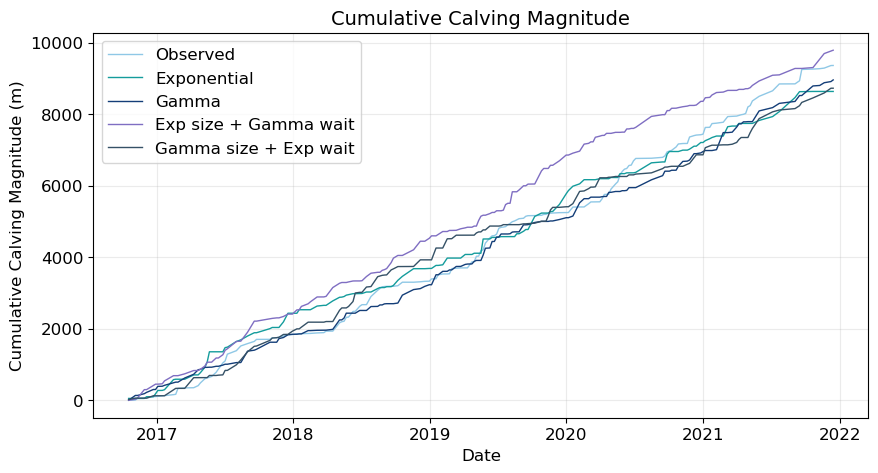

In [39]:
plt.plot(
    observed_interval["Date"],
    observed_interval_cumulative,
    color=light_blue,
    linewidth=1,
    label="Observed"
)

plt.plot(
    synthetic_exp_intervals["Date"],
    synthetic_exp_intervals["cumulative"],
    color=teal,
    linewidth=1,
    label="Exponential"
)

plt.plot(
    synthetic_gamma_intervals["Date"],
    synthetic_gamma_intervals["cumulative"],
    color=dark_blue,
    linewidth=1,
    label="Gamma"
)

plt.plot(
    synthetic_exp_gamma_I_intervals["Date"],
    synthetic_exp_gamma_I_intervals["cumulative"],
    color=light_purple,
    linewidth=1,
    label="Exp size + Gamma wait"
)

plt.plot(
    synthetic_gamma_exp_II_intervals["Date"],
    synthetic_gamma_exp_II_intervals["cumulative"],
    color=blue_2,
    linewidth=1,
    label="Gamma size + Exp wait"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Calving Magnitude (m)")
plt.title("Cumulative Calving Magnitude")
plt.grid(True, alpha=0.25)
plt.legend()

plt.show()

In [40]:
observed_total_b = observed_sorted["calving_positive"].sum()
exp_total_b = synthetic_exp_intervals["calving"].sum()
gamma_total_b = synthetic_gamma_intervals["calving"].sum()
exp_gamma_I_total_b = synthetic_exp_gamma_I_intervals["calving"].sum()
gamma_exp_II_total_b = synthetic_gamma_exp_II_intervals["calving"].sum()

print("Total Observed Calving:", observed_total_b, "m")
print("Total Synthetic Calving (Exponential):", exp_total_b, "m")
print("Total Synthetic Calving (Gamma):", gamma_total_b, "m")
print("Total Synthetic Calving (Exp/Gamma):", exp_gamma_I_total_b, "m")
print("Total Synthetic Calving (Gamma/Exp):", gamma_exp_II_total_b, "m")

Total Observed Calving: 9574.719542403524 m
Total Synthetic Calving (Exponential): 8633.084498914664 m
Total Synthetic Calving (Gamma): 8955.518571269264 m
Total Synthetic Calving (Exp/Gamma): 9785.690141082872 m
Total Synthetic Calving (Gamma/Exp): 8723.31117089428 m


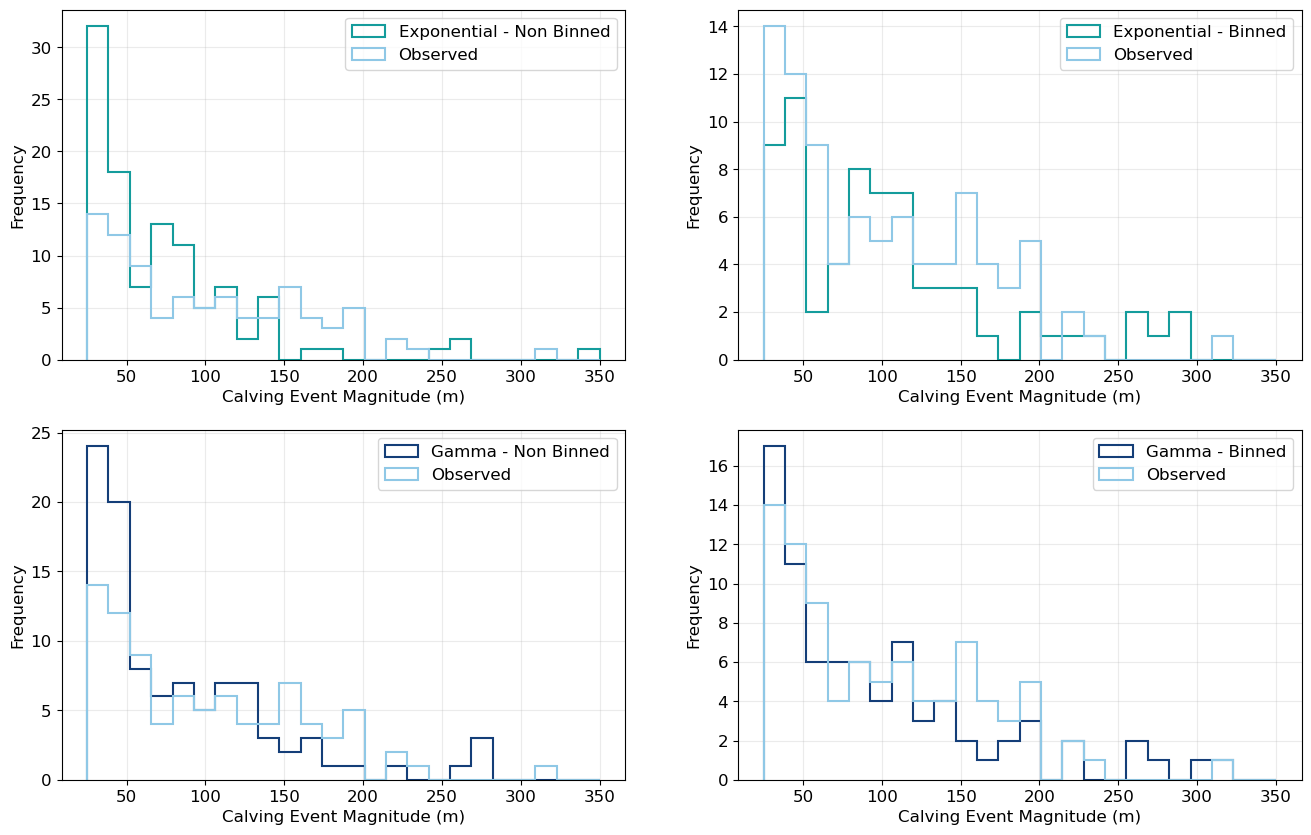

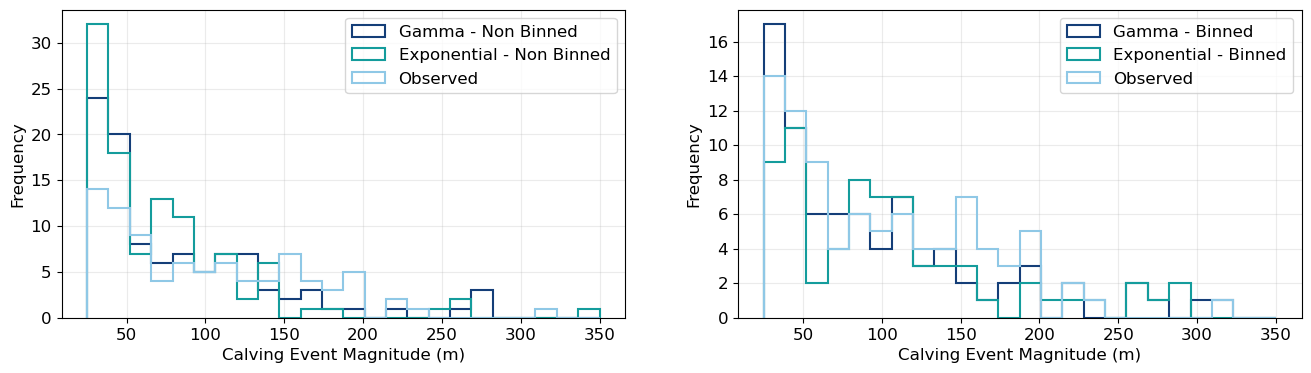

In [41]:
# histograma of calving magntiudes - observed,
# and then synthetic non binned, 
# and then synthetic binned

fig, ax  = plt.subplots(2, 2, figsize = (16,10))

# observed and exp - non binned
ax[0,0].hist(
    [observed["calving_positive"],
    synthetic_exp["synthetic_calving"]],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = [light_blue, teal],
    label = ["Observed", "Exponential - Non Binned"]
)

# observed and exp - binned
ax[0,1].hist(
    [observed["calving_positive"],
    synthetic_exp_intervals["calving"]],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = [light_blue, teal], 
    label = ["Observed", "Exponential - Binned"]
)

#observed and gamma - non binned
ax[1,0].hist(
    [observed["calving_positive"],
    synthetic_gamma["synthetic_calving"]],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = [light_blue, dark_blue],
    label = ["Observed", "Gamma - Non Binned"]
)
#observed and gamma - binned
ax[1,1].hist(
    [observed["calving_positive"],
    synthetic_gamma_intervals["calving"]],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = [light_blue, dark_blue],
    label = ["Observed", "Gamma - Binned"]
)

for ax in ax.ravel():
    ax.set_xlabel("Calving Event Magnitude (m)")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.show()

fig, ax = plt.subplots(1,2,  figsize=(16, 4))

ax[0].hist(
    [observed["calving_positive"],
    synthetic_exp["synthetic_calving"], synthetic_gamma["synthetic_calving"]],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = [light_blue, teal, dark_blue],
    label = ["Observed", "Exponential - Non Binned", "Gamma - Non Binned"]
)

ax[1].hist(
    [observed["calving_positive"],
    synthetic_exp_intervals["calving"], synthetic_gamma_intervals["calving"]],
    bins=np.linspace(25,350, 25),
    histtype="step",
    linewidth=1.5,
    color = [light_blue, teal, dark_blue],
    label = ["Observed", "Exponential - Binned", "Gamma - Binned"]
)

for ax in ax.ravel():
    ax.set_xlabel("Calving Event Magnitude (m)")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.25)
    ax.legend()



In [42]:
print(len(observed_interval.values))
print(len(synthetic_exp_intervals["calving"]))
print(len(synthetic_gamma_intervals["calving"]))
print(len(synthetic_exp_intervals["cumulative"]))
print(len(synthetic_gamma_intervals["cumulative"]))
print(len(observed_interval_cumulative))

180
180
180
180
180
180


In [43]:
#residual = observed - model/synthetic

residual_exp_magnitude = (observed_interval.values - synthetic_exp_intervals["calving"].values)
residual_gamma_magnitude = (observed_interval.values - synthetic_gamma_intervals["calving"].values)

residual_exp = observed_interval_cumulative - synthetic_exp_intervals["cumulative"]
residual_gamma = observed_interval_cumulative - synthetic_gamma_intervals["cumulative"]

print(len(residual_exp_magnitude))
print(len(residual_gamma_magnitude))
print(len(residual_exp))
print(len(residual_gamma))
print(len(observed_interval_cumulative))

180
180
180
180
180


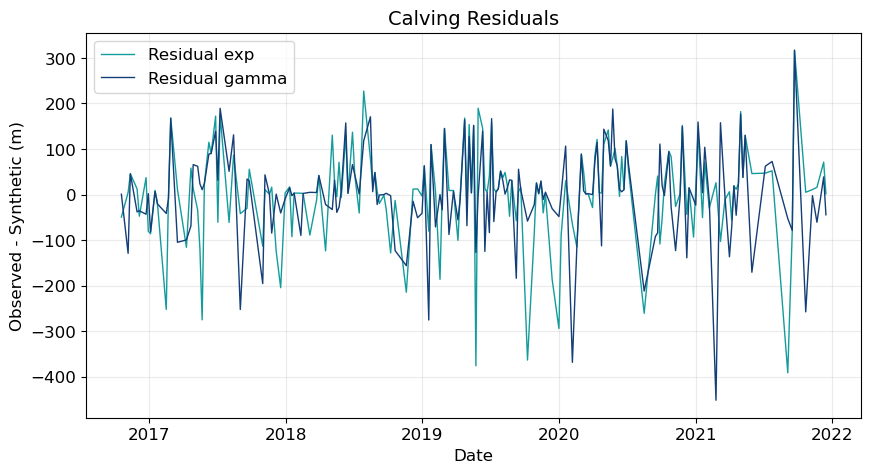

In [44]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(interval_dates, residual_exp_magnitude, color=teal, linewidth=1, label="Residual exp")
ax.plot(interval_dates, residual_gamma_magnitude, color=dark_blue, linewidth=1, label="Residual gamma")
ax.set_xlabel("Date")
ax.set_ylabel("Observed - Synthetic (m)")
ax.set_title("Calving Residuals")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


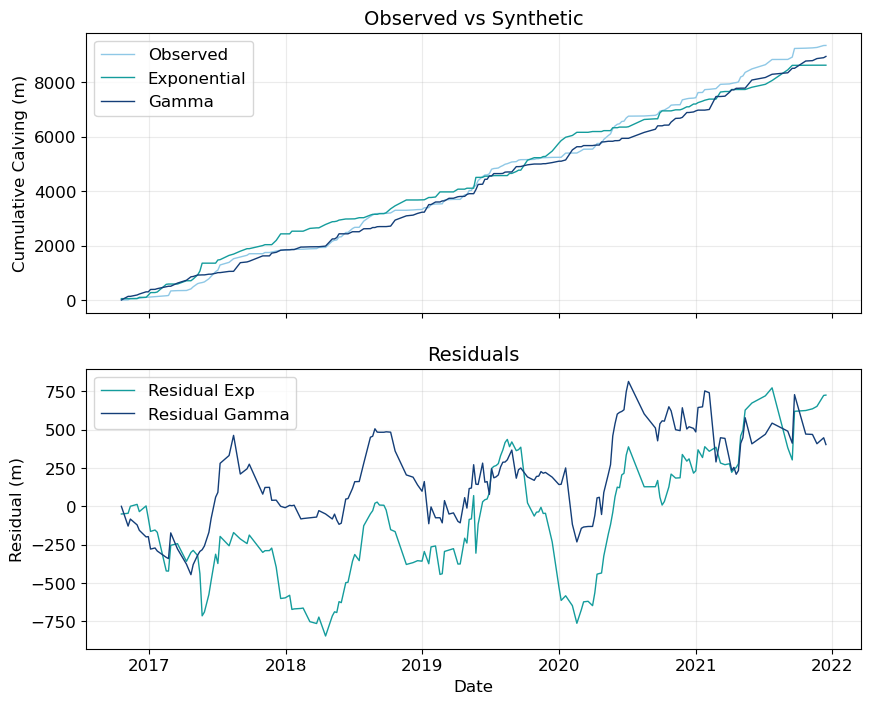

In [45]:
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(10, 8),sharex=True)

ax[0].plot(interval_dates, observed_interval_cumulative, color=light_blue, linewidth=1,label="Observed")
ax[0].plot(interval_dates, synthetic_exp_intervals["cumulative"], color=teal, linewidth=1, label="Exponential")
ax[0].plot(interval_dates, synthetic_gamma_intervals["cumulative"], color=dark_blue, linewidth=1, label="Gamma")
ax[0].set_ylabel("Cumulative Calving (m)")
ax[0].set_title("Observed vs Synthetic")
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].plot(interval_dates, residual_exp, color=teal, linewidth=1, label="Residual Exp")
ax[1].plot(interval_dates, residual_gamma, color=dark_blue, linewidth=1, label="Residual Gamma")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Residual (m)")
ax[1].set_title("Residuals")
ax[1].grid(True, alpha=0.25)
ax[1].legend()

plt.show()

### 4. Rerunning the model
How does this averaged compare to the observed?
1. Exponentially distributed synthetic

2. Gamma distributed synthetic

3. Exponential & gamma combined - and vice versa - 
_focus on just 1. and 2. for now!_


In [46]:
## 1. Exponential distribution of event sizes and waiting times
    # run 100 times 

seeds = range(100)

exp_calving_runs = []
exp_totals = []

for seed in seeds:
    synthetic_exp_s = exp_calving(
        start_date=observed["Date"].min(),
        end_date=observed["Date"].max(),
        time_scale=time_exp,
        size_scale=size_exp,
        seed=seed
    )
    exp_calving_runs.append(synthetic_exp_s)
    exp_totals.append(synthetic_exp_s["synthetic_calving"].sum())

print("Average total calving (exp synthetic):", np.mean(exp_totals), "m")
print("Standard deviation of total calving (exp synthetic):", np.std(exp_totals), "m")
print("Total Observed Calving:", observed_total_b, "m")


Average total calving (exp synthetic): 9393.127396792044 m
Standard deviation of total calving (exp synthetic): 928.4730226686244 m
Total Observed Calving: 9574.719542403524 m


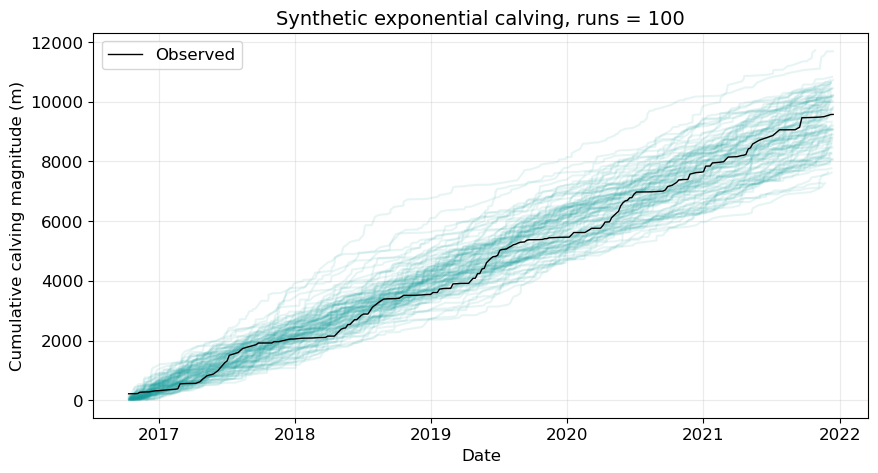

In [47]:
#cumulative sum of each synthetic exp run 
    ## and plot!
fig, ax = plt.subplots(figsize=(10, 5))

for run in exp_calving_runs:
    cumulative = run["synthetic_calving"].cumsum()
    ax.plot(run["Date"], cumulative, color=teal, alpha=0.10)

ax.plot(observed["Date"], observed_cumulative, color="black", linewidth=1, label="Observed")
ax.legend()
ax.grid(True, alpha=0.25)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative calving magnitude (m)")
ax.set_title("Synthetic exponential calving, runs = 100")
plt.show()



In [48]:
## 2. Gamma distribution of event sizes and waiting times
    # run 100 times 

seeds = range(100)

gamma_calving_runs = []
gamma_totals = []

for seed in seeds:
    synthetic_gamma_s = gamma_calving(
        start_date=observed["Date"].min(),
        end_date=observed["Date"].max(),
        time_shape=time_shape,
        time_scale=time_scale,
        size_shape=size_shape,
        size_scale=size_scale,
        seed=seed
    )

    gamma_calving_runs.append(synthetic_gamma_s)
    gamma_totals.append(synthetic_gamma_s["synthetic_calving"].sum())

print("Average total calving (gamma synthetic):", np.mean(gamma_totals), "m")
print("Standard deviation of total calving (gamma synthetic):", np.std(gamma_totals), "m")
print("Total Observed Calving:", observed_total_b, "m")

Average total calving (gamma synthetic): 9484.231042825422 m
Standard deviation of total calving (gamma synthetic): 976.8469968908756 m
Total Observed Calving: 9574.719542403524 m


<function matplotlib.pyplot.show(close=None, block=None)>

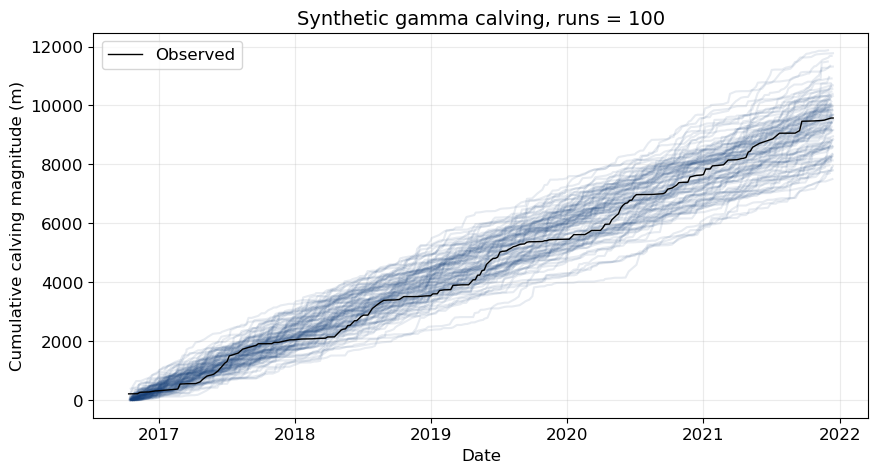

In [49]:
#cumulative sum of each gamma exp run
    # and plot 

fig, ax = plt.subplots(figsize=(10, 5))

for run in gamma_calving_runs:
    cumulative = run["synthetic_calving"].cumsum()
    ax.plot(run["Date"], cumulative, color=dark_blue, alpha=0.10)

ax.plot(observed["Date"], observed_cumulative, color="black", linewidth=1, label="Observed")
ax.legend()
ax.grid(True, alpha=0.25)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative calving magnitude (m)")
ax.set_title("Synthetic gamma calving, runs = 100") 
plt.show

### 5a. Fitting multiple distributions to the calving series
- Based on calving magnitude size (could potentially look at frequency later...)

- Using Bézu et Bartholomaus (2024)
    - a) kilometer-scale step retreats = tabular rifting 
    - b) step retreats > 200 m = slab capsize 
    - c) smaller step retreats, < 200 m  = serac collapse 
    - < 100 m = serac failures - serac failure is pseudo-continuous over timescales greater than an hour 

BUT is also says "Glacier undergoes retreat through a distribution of event sizes; nearly all glaciers include at least some # small step retreats (<100 m), but the glaciers differ significantly in the relative occurrence of larger calving events (>200 m). 

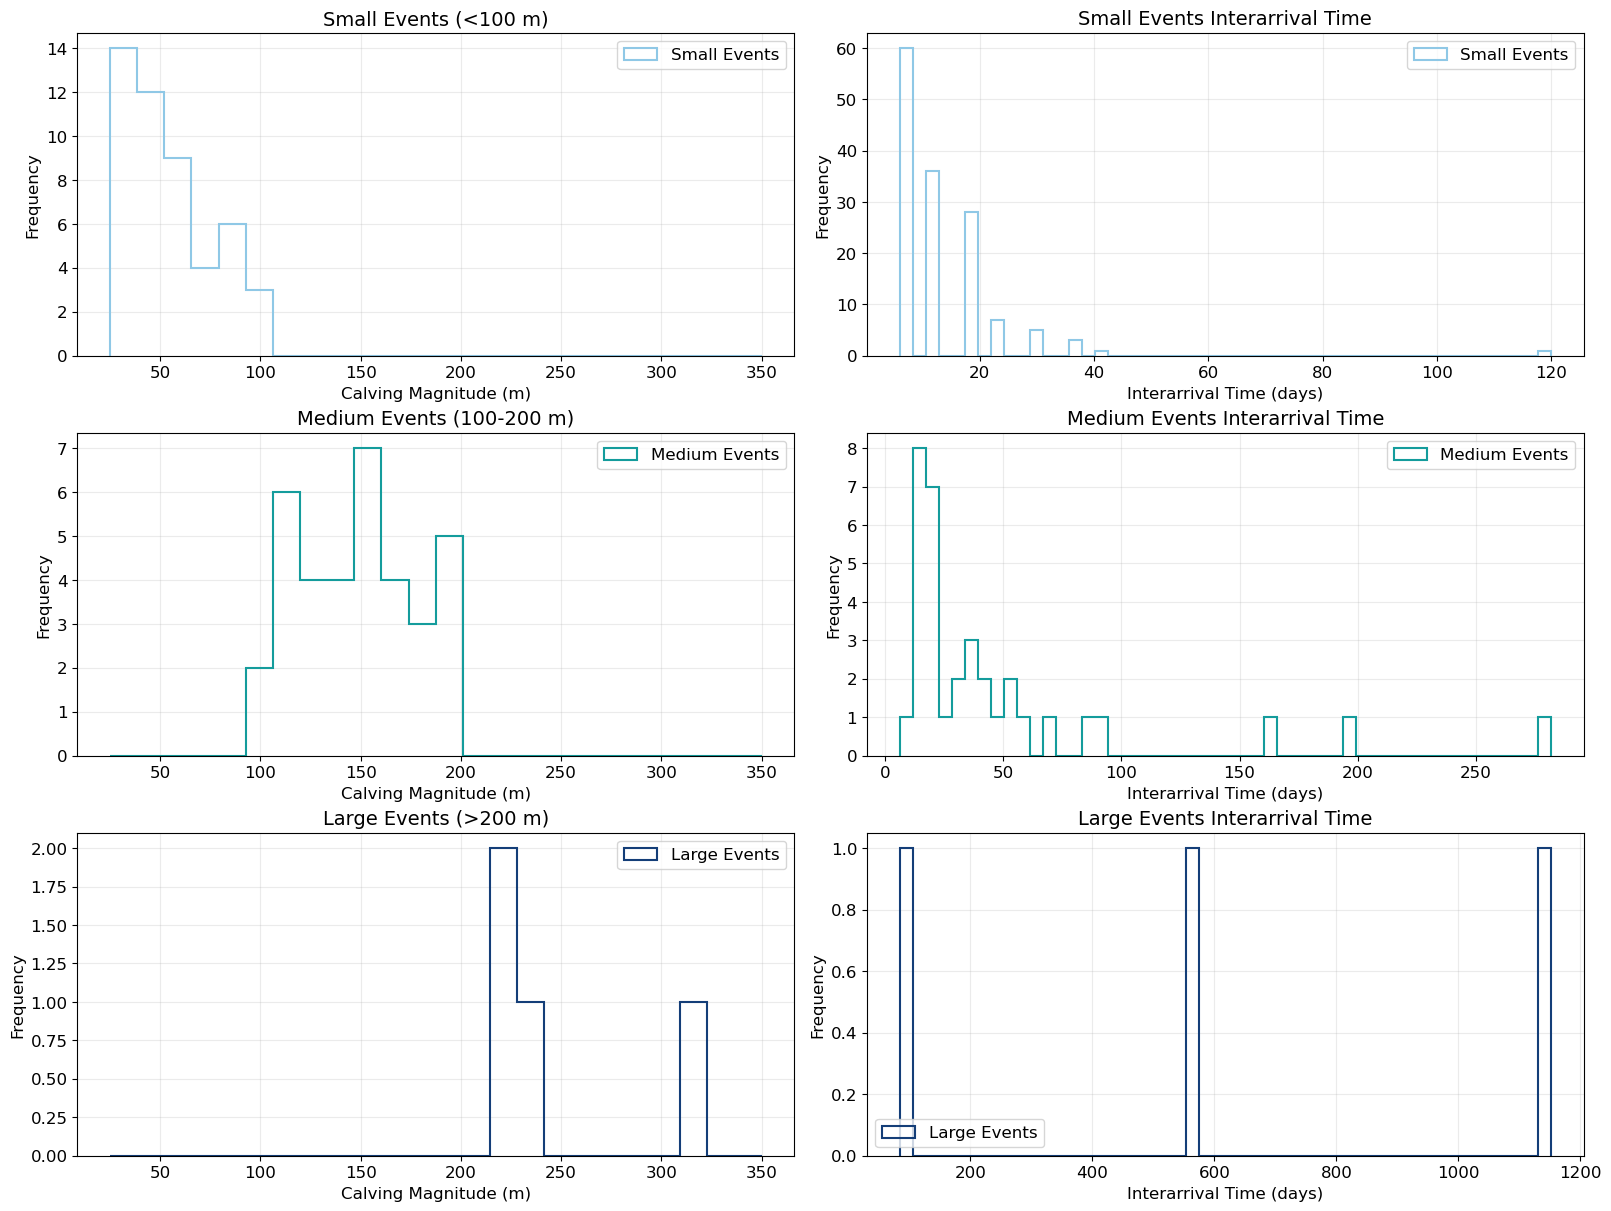

In [50]:
# look at dividing the observed calving events into smaller groups (by calving mag. size or time)
# pg. 5,  Bézu et Bartholomaus (2024)
 

# so maybe i do <100 m , 100-200 m, and > 200 m 

small_events = observed[observed["calving_positive"] < 100]
medium_events = observed[(observed["calving_positive"] >= 100) & (observed["calving_positive"] < 200)]
large_events = observed[observed["calving_positive"] >= 200]

fig, ax = plt.subplots(3,2, figsize=(16, 12), constrained_layout=True)

#small events 
ax[0,0].hist(small_events["calving_positive"],bins=np.linspace(25,350, 25), histtype="step",linewidth=1.5,color=light_blue,label = "Small Events")
ax[0,0].set_xlabel("Calving Magnitude (m)")
ax[0,0].set_ylabel("Frequency")
ax[0,0].set_title("Small Events (<100 m)")
ax[0,0].grid(True, alpha=0.25)
ax[0,0].legend()

ax[0,1].hist(small_events["Date"].diff().dt.days.dropna(),bins = 50,histtype="step",linewidth=1.5,color=light_blue,label = "Small Events")
ax[0,1].set_xlabel("Interarrival Time (days)")
ax[0,1].set_ylabel("Frequency")
ax[0,1].set_title("Small Events Interarrival Time")
ax[0,1].grid(True, alpha=0.25)
ax[0,1].legend()

# medium events 
ax[1,0].hist(medium_events["calving_positive"],bins = np.linspace(25,350, 25),histtype="step",linewidth=1.5,color=teal,label = "Medium Events")
ax[1,0].set_xlabel("Calving Magnitude (m)")
ax[1,0].set_ylabel("Frequency")
ax[1,0].set_title("Medium Events (100-200 m)")
ax[1,0].grid(True, alpha=0.25)
ax[1,0].legend()

ax[1,1].hist(medium_events["Date"].diff().dt.days.dropna(),bins = 50,histtype="step",linewidth=1.5,color=teal,label = "Medium Events")
ax[1,1].set_xlabel("Interarrival Time (days)")
ax[1,1].set_ylabel("Frequency")
ax[1,1].set_title("Medium Events Interarrival Time")
ax[1,1].grid(True, alpha=0.25)
ax[1,1].legend()

#large events
ax[2,0].hist(large_events["calving_positive"],bins = np.linspace(25,350, 25),histtype="step",linewidth=1.5,color=dark_blue,label = "Large Events")
ax[2,0].set_xlabel("Calving Magnitude (m)")
ax[2,0].set_ylabel("Frequency")
ax[2,0].set_title("Large Events (>200 m)")
ax[2,0].grid(True, alpha=0.25)
ax[2,0].legend()

ax[2,1].hist(large_events["Date"].diff().dt.days.dropna(),bins = 50,histtype="step",linewidth=1.5,color=dark_blue,label = "Large Events")
ax[2,1].set_xlabel("Interarrival Time (days)")
ax[2,1].set_ylabel("Frequency")
ax[2,1].set_title("Large Events Interarrival Time")
ax[2,1].grid(True, alpha=0.25)
ax[2,1].legend()
plt.show()

In [51]:
n_small = len(small_events)
n_medium = len(medium_events)
n_large = len(large_events)
n_total = len(observed)

small_total = small_events["calving_positive"].sum()
medium_total = medium_events["calving_positive"].sum()
large_total = large_events["calving_positive"].sum()
# observed_total_b = observed total 

print("Number of small events:", n_small)
print("Number of medium events:", n_medium)
print("Number of large events:", n_large)

print("Fraction of small events:", n_small / n_total)
print("Fration of medium events:", n_medium / n_total)
print("Fraction of large events:", n_large / n_total)

print("Total calving magnitude for small events:", small_total, "m")
print("Total calving magnitude for medium events:", medium_total, "m")
print("Total calving magnitude for large events:", large_total, "m")

print("Fraction of total calving magnitude for small events:", small_total / observed_total_b)
print("Fraction of total calving magnitude for medium events:", medium_total / observed_total_b)
print("Fraction of total calving magnitude for large events:", large_total / observed_total_b)

Number of small events: 142
Number of medium events: 35
Number of large events: 4
Fraction of small events: 0.7845303867403315
Fration of medium events: 0.19337016574585636
Fraction of large events: 0.022099447513812154
Total calving magnitude for small events: 3377.0892094176706 m
Total calving magnitude for medium events: 5206.851582864154 m
Total calving magnitude for large events: 990.7787501216983 m
Fraction of total calving magnitude for small events: 0.35270894300993033
Fraction of total calving magnitude for medium events: 0.5438124385580789
Fraction of total calving magnitude for large events: 0.10347861843199065
